In [4]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d amananandrai/ag-news-classification-dataset

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
License(s): unknown
ag-news-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip /content/ag-news-classification-dataset.zip

Archive:  /content/ag-news-classification-dataset.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
import pandas as pd

df = pd.read_csv("/content/test.csv")
df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [8]:
df.describe()

,Class Index
count,7600.000000
mean,2.500000
std,1.118108
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [9]:
df["Class Index"].value_counts()

,count
Class Index,
3,1900
4,1900
2,1900
1,1900


In [10]:
df["text"] = df["Title"] +" "+df['Description']

df = df.drop(["Title", "Description"], axis= 1)
df.head()

,Class Index,text
0,3,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP) AP...


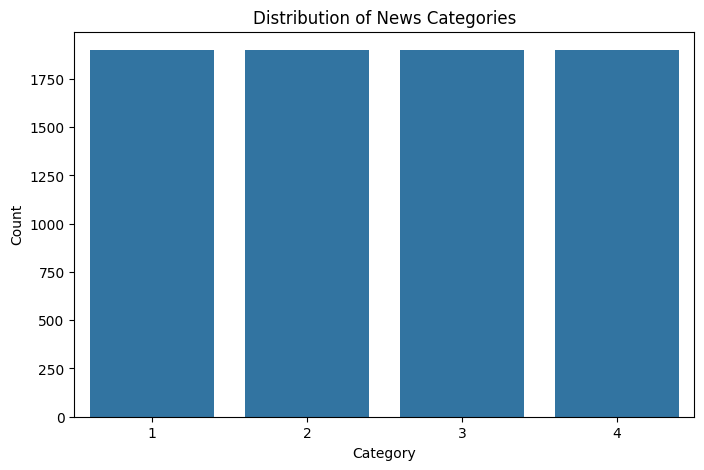

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Class Index')

plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


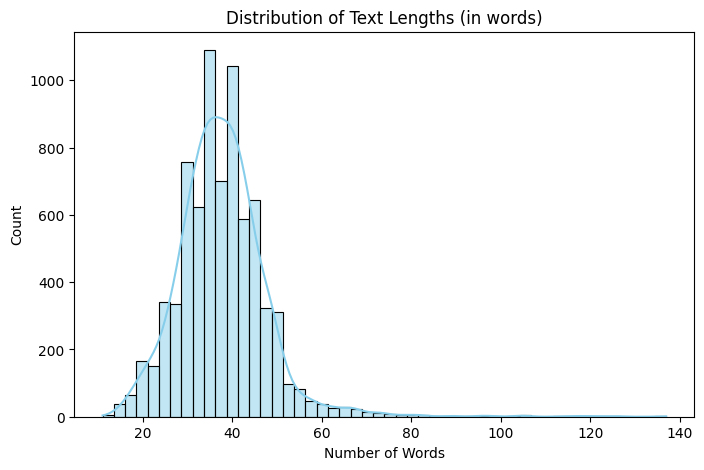

In [12]:
text_len = df['text'].apply(lambda x: len(x.split()))


plt.figure(figsize=(8,5))
sns.histplot(text_len, bins=50, kde=True, color='skyblue')
plt.title("Distribution of Text Lengths (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()


### Preprocessing text

In [13]:
def to_lower(text):
 text = text.lower()
 return text
df["text"] = df["text"].apply(to_lower)
df.head()

,Class Index,text
0,3,fears for t n pension after talks unions repre...
1,4,the race is on: second private team sets launc...
2,4,ky. company wins grant to study peptides (ap) ...
3,4,prediction unit helps forecast wildfires (ap) ...
4,4,calif. aims to limit farm-related smog (ap) ap...


In [14]:
import string
def remove_punctuation(text):
  text =text.translate(str.maketrans("", "", string.punctuation))
  return text
df ['text'] = df['text'].apply(remove_punctuation)

df.head()

,Class Index,text
0,3,fears for t n pension after talks unions repre...
1,4,the race is on second private team sets launch...
2,4,ky company wins grant to study peptides ap ap ...
3,4,prediction unit helps forecast wildfires ap ap...
4,4,calif aims to limit farmrelated smog ap ap so...


In [15]:
import re

def remove_special_char(text):
  text= re.sub(r"[^A-Za-z]"," ", text)
  return text
df["text"] = df["text"].apply(remove_special_char)
df.head()

,Class Index,text
0,3,fears for t n pension after talks unions repre...
1,4,the race is on second private team sets launch...
2,4,ky company wins grant to study peptides ap ap ...
3,4,prediction unit helps forecast wildfires ap ap...
4,4,calif aims to limit farmrelated smog ap ap so...


In [16]:
df.loc[:, 'text'] = df['text'].apply(lambda x: ' '.join([w for w in x.split() if len(w) > 3]))
df.head()

,Class Index,text
0,3,fears pension after talks unions representing ...
1,4,race second private team sets launch date huma...
2,4,company wins grant study peptides company foun...
3,4,prediction unit helps forecast wildfires barel...
4,4,calif aims limit farmrelated smog southern cal...


In [17]:
def normalize_repeated_chars(text):
  text = re.sub(r"(.)\1{2,}", r"\1\1", text)
  return text.strip()
df["text"] = df["text"].apply(normalize_repeated_chars)
df.head()

,Class Index,text
0,3,fears pension after talks unions representing ...
1,4,race second private team sets launch date huma...
2,4,company wins grant study peptides company foun...
3,4,prediction unit helps forecast wildfires barel...
4,4,calif aims limit farmrelated smog southern cal...


In [18]:
def remove_short_words(text, min_length=3):
    words = [w for w in str(text).split() if len(w) >= min_length]

    return " ".join(words)

df['text'] = df['text'].apply(remove_short_words)

df.head()


,Class Index,text
0,3,fears pension after talks unions representing ...
1,4,race second private team sets launch date huma...
2,4,company wins grant study peptides company foun...
3,4,prediction unit helps forecast wildfires barel...
4,4,calif aims limit farmrelated smog southern cal...


In [19]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

In [20]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
  tokens = word_tokenize(text)
  return tokens

tokens = df['text'].apply(tokenize_text)
tokens.head()

,text
0,"[fears, pension, after, talks, unions, represe..."
1,"[race, second, private, team, sets, launch, da..."
2,"[company, wins, grant, study, peptides, compan..."
3,"[prediction, unit, helps, forecast, wildfires,..."
4,"[calif, aims, limit, farmrelated, smog, southe..."


In [21]:
from nltk.corpus import stopwords
nltk.download('stopwords',quiet=True )

def remove_stopwords_preserve_negation(tokens):

    stop_words= set(stopwords.words('english'))
    negation_words = {
        'not', "n't", "no", "never", "none", "nobody", "nothing", "nowhere",
        "neither", "nor", "cannot", "can't", "won't", "wouldn't", "couldn't",
        "shouldn't", "isn't", "aren't", "wasn't", "weren't", "don't", "doesn't",
        "didn't", "haven't", "hasn't", "hadn't", "mustn't", "mightn't", "needn't"}

    filtered_stopwords= stop_words - negation_words

    filtered_tokens = [token for token in tokens if token not in filtered_stopwords]

    return filtered_tokens
filtered_tokens= tokens.apply(remove_stopwords_preserve_negation)
filtered_tokens.head()


,text
0,"[fears, pension, talks, unions, representing, ..."
1,"[race, second, private, team, sets, launch, da..."
2,"[company, wins, grant, study, peptides, compan..."
3,"[prediction, unit, helps, forecast, wildfires,..."
4,"[calif, aims, limit, farmrelated, smog, southe..."


In [22]:
import nltk
from nltk.corpus import wordnet
from nltk.stem.wordnet import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [23]:
def get_wordnet_pos(treebank_tag):
   if treebank_tag.startswith('J'):
        return wordnet.ADJ
   elif treebank_tag.startswith('V'):
        return wordnet.VERB
   elif treebank_tag.startswith('N'):
        return wordnet.NOUN
   elif treebank_tag.startswith('R'):
        return wordnet.ADV
   else:
        return wordnet.NOUN


In [24]:
def lemmatize_tokens_list(tokens):

   lem = WordNetLemmatizer()
   pos_tags= nltk.pos_tag(tokens)
   lemmatized = [lem.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags ]
   return lemmatized

lemmatized_tokens = filtered_tokens.apply(lemmatize_tokens_list)
lemmatized_tokens.head()



,text
0,"[fear, pension, talk, union, represent, worker..."
1,"[race, second, private, team, set, launch, dat..."
2,"[company, win, grant, study, peptide, company,..."
3,"[prediction, unit, help, forecast, wildfire, b..."
4,"[calif, aim, limit, farmrelated, smog, souther..."


In [25]:
df.loc[:, 'text'] = lemmatized_tokens.apply(lambda x: ' '.join(x))

df.head()

,Class Index,text
0,3,fear pension talk union represent worker turne...
1,4,race second private team set launch date human...
2,4,company win grant study peptide company found ...
3,4,prediction unit help forecast wildfire barely ...
4,4,calif aim limit farmrelated smog southern cali...


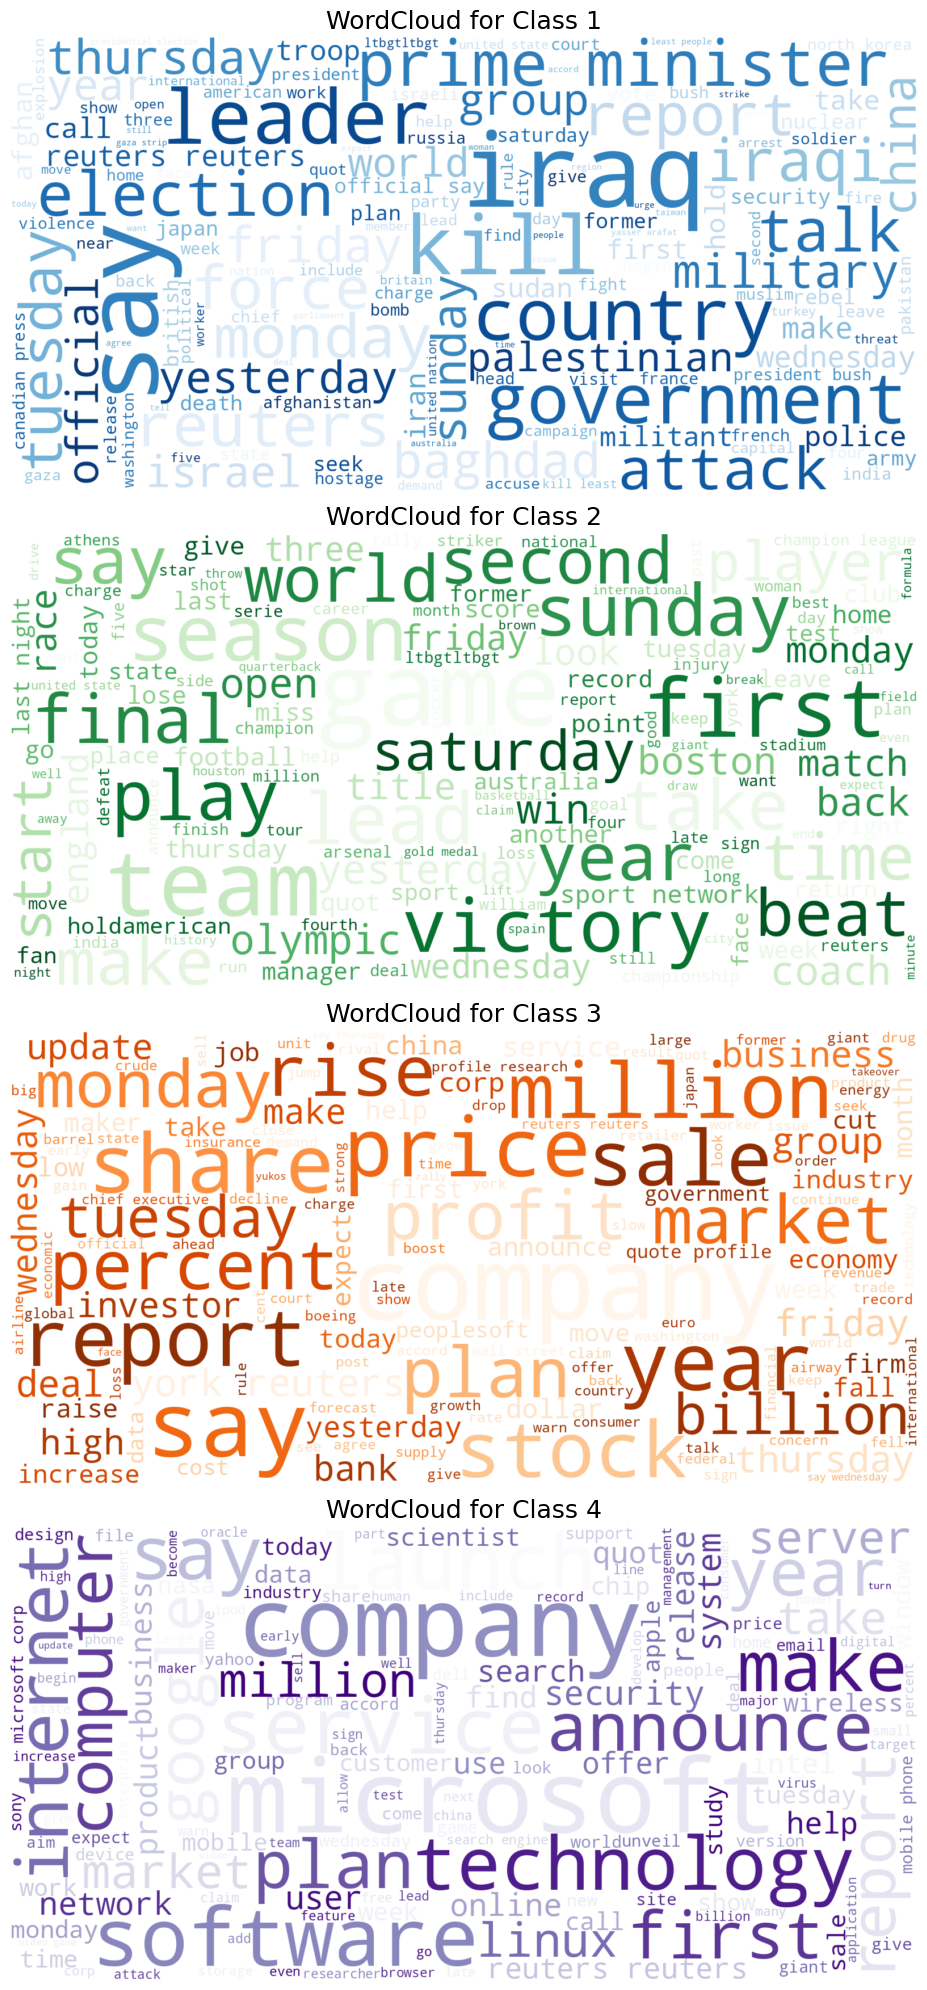

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

colors = ['Blues', 'Greens', 'Oranges', 'Purples']

plt.figure(figsize=(12, 20))

for i, cls in enumerate([1, 2, 3, 4]):
    text = " ".join(df[df['Class Index'] == cls]['text'].astype(str))

    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='white',
        colormap=colors[i],
        max_words=150,
        max_font_size=180
    ).generate(text)

    plt.subplot(4, 1, i + 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for Class {cls}", fontsize=18)

plt.tight_layout()
plt.show()


## Text Vectorization
Tfidf Vectorizer

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words= 'english', max_df= .90 , min_df= 4 , max_features= 5000
)

tfidf_features = tfidf_vectorizer.fit_transform(df['text'])

tfidf_features =tfidf_features.toarray()
tfidf_features

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Spliting data

In [30]:
from sklearn.model_selection import train_test_split

X = tfidf_features
y = df["Class Index"]
X_train , X_test , y_train , y_test = train_test_split(X , y, test_size= .20 , random_state= 42, shuffle=True)


### Modeling LogisticRegression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

log = LogisticRegression(max_iter= 1000, random_state= 42)
log.fit(X_train, y_train)

y_pred_train= log.predict(X_train)
y_pred_test= log.predict(X_test)

print(f"Accuracy of train: {accuracy_score(y_train, y_pred_train)*100:.3f}")
print(f"Accuracy of test: { accuracy_score(y_test, y_pred_test)*100:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


Accuracy of train: 93.898
Accuracy of test: 87.763

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.89      0.89       373
           2       0.91      0.95      0.93       389
           3       0.84      0.83      0.84       359
           4       0.87      0.83      0.85       399

    accuracy                           0.88      1520
   macro avg       0.88      0.88      0.88      1520
weighted avg       0.88      0.88      0.88      1520



### SVM (Support Vector Machine)

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42, C=1.0)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8651315789473685

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.90      0.88       373
           2       0.93      0.92      0.93       389
           3       0.81      0.83      0.82       359
           4       0.85      0.81      0.83       399

    accuracy                           0.87      1520
   macro avg       0.86      0.87      0.86      1520
weighted avg       0.87      0.87      0.87      1520

